In [1]:
!pip install -q langchain langchain-mistralai langchain-community langgraph python-dotenv faiss-cpu pypdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.5/395.5 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [2]:
from langchain_mistralai import ChatMistralAI, MistralAIEmbeddings
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.prebuilt import ToolNode, tools_condition

/tmp/ipykernel_493/1309324248.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


In [3]:
from google.colab import userdata
import os
os.environ["MISTRAL_API_KEY"] = userdata.get('MISTRAL_API_KEY')

In [4]:
from google.colab import files
uploaded = files.upload()   # a file picker appears -- select dl-curriculum.pdf

Saving dl-curriculum.pdf to dl-curriculum (1).pdf


In [5]:
# DELIBERATELY hardcoded, not read from a shared env var -- see
# MISTRAL_MODEL_LIMITS.md: mistral-small-latest has ZERO request allowance on
# many accounts (hard 429, not a speed issue). ministral-8b-latest is the
# confirmed-working default.
llm = ChatMistralAI(model="ministral-8b-latest")

In [6]:
loader = PyPDFLoader("dl-curriculum.pdf")
docs = loader.load()

In [7]:
len(docs)

23

In [8]:
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = splitter.split_documents(docs)

In [9]:
len(chunks)

23

In [10]:
embeddings = MistralAIEmbeddings(model="mistral-embed")
vector_store = FAISS.from_documents(chunks, embeddings)

tokenizer.json:   0%|          | 0.00/1.80M [00:00<?, ?B/s]

In [11]:
vector_store

In [12]:
retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k': 4})

In [13]:
@tool
def rag_tool(query):
    """
    Retrieve relevant information from the pdf document.
    Use this tool when the user asks factual / conceptual questions
    that might be answered from the stored documents.
    """
    result = retriever.invoke(query)

    context = [doc.page_content for doc in result]
    metadata = [doc.metadata for doc in result]

    return {
        'query': query,
        'context': context,
        'metadata': metadata
    }

In [14]:
tools = [rag_tool]
llm_with_tools = llm.bind_tools(tools)

In [15]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [16]:
def chat_node(state: ChatState):
    messages = state['messages']
    response = llm_with_tools.invoke(messages)
    return {'messages': [response]}

In [17]:
tool_node = ToolNode(tools)

In [18]:
graph = StateGraph(ChatState)

graph.add_node('chat_node', chat_node)
graph.add_node('tools', tool_node)

graph.add_edge(START, 'chat_node')
graph.add_conditional_edges('chat_node', tools_condition)
graph.add_edge('tools', 'chat_node')

chatbot = graph.compile()

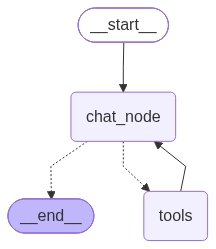

In [19]:
from IPython.display import Image, display
display(Image(chatbot.get_graph().draw_mermaid_png()))

In [20]:
result = chatbot.invoke(
    {
        "messages": [
            HumanMessage(
                content=(
                    "what is this pdf all about"
                )
            )
        ]
    }
)

In [21]:
print(result['messages'][-1].content)

This PDF is titled **"Deep Learning Curriculum"** and covers a comprehensive overview of deep learning concepts. Here’s a summary of the key topics discussed in the document:

---

### **Key Topics Covered:**

#### **1. Convolutional Neural Networks (CNNs)**
   - **Convolution Operation**:
     - Understanding kernels/filters, their role in edge detection and feature extraction.
     - Mathematical representation of convolution in 2D and 3D.
     - Hyperparameters like kernel size, depth, stride, and padding (same vs. valid).
   - **Activation Functions**:
     - ReLU (Rectified Linear Unit) and its advantages over sigmoid/tanh.
     - Variants like Leaky ReLU and ELU (Exponential Linear Unit).
   - **Pooling Layers**:
     - Purpose: Dimensionality reduction and translation invariance.
     - Types: Max pooling and average pooling.
     - Pooling size and stride.

#### **2. Architectures and Models**
   - **AlexNet**:
     - Breakthroughs like deeper networks and the use of ReLU.
    